# LeetCode #1095: Find in Mountain Array

https://leetcode.com/problems/find-in-mountain-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan via API)** | $O(n)$ | $O(1)$ |
| **Optimal: Three Binary Searches ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan via API)
Query every index left to right, returning the first match. $O(n)$ API calls; too slow for large mountain arrays.

### Optimal: Three Binary Searches ★
1. Find the peak index (first binary search on the gradient: if `get(mid) < get(mid+1)` peak is right, else left).
2. Binary search the ascending left half for target.
3. If not found, binary search the descending right half. Return the smallest valid index (left half preferred).
Each phase is $O(\log n)$; total $O(\log n)$ with $O(1)$ space.

**Constraints:**
* 3 <= mountain_arr.length() <= 10^4
* 1 <= target <= 10^8
* 0 <= mountain_arr.get(index) <= 10^8
* mountain_arr.get calls are limited (100 calls maximum)


## Solutions

### C#

In [ ]:
// MountainArray is the API interface provided by the problem
public int FindInMountainArray(int target, MountainArray mountainArr) {
    int n = mountainArr.length();
    // Phase 1: Find peak index
    int lo = 0, hi = n - 1;
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        if (mountainArr.get(mid) < mountainArr.get(mid + 1)) lo = mid + 1;
        else hi = mid;
    }
    int peak = lo;
    // Phase 2: Binary search ascending left half
    lo = 0; hi = peak;
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        int val = mountainArr.get(mid);
        if (val == target) return mid;
        if (val < target) lo = mid + 1; else hi = mid - 1;
    }
    // Phase 3: Binary search descending right half
    lo = peak + 1; hi = n - 1;
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        int val = mountainArr.get(mid);
        if (val == target) return mid;
        if (val > target) lo = mid + 1; else hi = mid - 1;  // Descending: larger left
        // Note: comparisons are inverted — larger values are to the left in right half
    }
    return -1;
}


### Python

In [ ]:
def findInMountainArray(self, target: int, mountain_arr) -> int:
    n = mountain_arr.length()
    # Phase 1: Find peak index
    lo, hi = 0, n - 1
    while lo < hi:
        mid = lo + (hi - lo) // 2
        if mountain_arr.get(mid) < mountain_arr.get(mid + 1):
            lo = mid + 1
        else:
            hi = mid
    peak = lo
    # Phase 2: Binary search ascending left half
    lo, hi = 0, peak
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        val = mountain_arr.get(mid)
        if val == target: return mid
        if val < target: lo = mid + 1
        else: hi = mid - 1
    # Phase 3: Binary search descending right half
    lo, hi = peak + 1, n - 1
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        val = mountain_arr.get(mid)
        if val == target: return mid
        if val > target: lo = mid + 1  # Descending: larger values left
        else: hi = mid - 1
    return -1


### Go

In [ ]:
func findInMountainArray(target int, mountainArr MountainArray) int {
    n := mountainArr.length()
    // Phase 1: Find peak index
    lo, hi := 0, n-1
    for lo < hi {
        mid := lo + (hi-lo)/2
        if mountainArr.get(mid) < mountainArr.get(mid+1) { lo = mid + 1 } else { hi = mid }
    }
    peak := lo
    // Phase 2: Binary search ascending left half
    lo, hi = 0, peak
    for lo <= hi {
        mid := lo + (hi-lo)/2
        val := mountainArr.get(mid)
        if val == target { return mid }
        if val < target { lo = mid + 1 } else { hi = mid - 1 }
    }
    // Phase 3: Binary search descending right half
    lo, hi = peak+1, n-1
    for lo <= hi {
        mid := lo + (hi-lo)/2
        val := mountainArr.get(mid)
        if val == target { return mid }
        if val > target { lo = mid + 1 } else { hi = mid - 1 }  // Descending: larger left
    }
    return -1
}


### Rust

In [ ]:
pub fn find_in_mountain_array(target: i32, mountain_arr: &MountainArray) -> i32 {
    let n = mountain_arr.length() as usize;
    // Phase 1: Find peak index
    let (mut lo, mut hi) = (0usize, n - 1);
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        if mountain_arr.get(mid as i32) < mountain_arr.get(mid as i32 + 1) {
            lo = mid + 1;
        } else {
            hi = mid;
        }
    }
    let peak = lo;
    // Phase 2: Binary search ascending left half
    let (mut lo, mut hi) = (0usize, peak);
    while lo <= hi {
        let mid = lo + (hi - lo) / 2;
        let val = mountain_arr.get(mid as i32);
        if val == target { return mid as i32; }
        if val < target { lo = mid + 1; } else { if mid == 0 { break; } hi = mid - 1; }
    }
    // Phase 3: Binary search descending right half
    let (mut lo, mut hi) = (peak + 1, n - 1);
    while lo <= hi {
        let mid = lo + (hi - lo) / 2;
        let val = mountain_arr.get(mid as i32);
        if val == target { return mid as i32; }
        if val > target { lo = mid + 1; } else { if mid == 0 { break; } hi = mid - 1; }  // Descending: larger left
    }
    -1
}


## Example Scenarios

**1. Common Case**
**Input:** array = [1, 2, 3, 4, 5, 3, 1], target = 3
Phase 1 (peak): mid=3(4)<get(4)=5→lo=4; mid=5(3)>get(4) wait — array[5]=3<array[4]=5? No, 3<5 so lo=5? Actually: get(mid=3)=4<get(4)=5→lo=4; get(4)=5>get(5)=3→hi=4; peak=4. Phase 2 [0,4]: mid=2(3)=target→return 2. Left half answer preferred (smallest index).

**2. Slightly Complex**
**Input:** array = [1, 5, 3], target = 3
Peak: get(0)=1<get(1)=5→lo=1; get(1)=5>get(2)=3→hi=1; peak=1. Phase 2 [0,1]: mid=0(1)<3→lo=1; get(1)=5≠3→hi=0; not found. Phase 3 [2,2]: get(2)=3=target→return 2.

**3. Edge Case: Time Factor**
**Input:** array = [0,1,2,...,5000,4999,...,0], target at index 1 (earliest occurrence)
Three phases each cost $\lceil \log_2(10^4) \rceil = 14$ calls. Total ≈ 42 get() calls — well within the 100-call limit. Phase 2 returns index 1 before Phase 3 runs.

**4. Edge Case: Space Factor**
**Input:** array = [0, 1, 0], target = 1 (only at peak)
Peak: get(0)=0<get(1)=1→lo=1; peak=1. Phase 2 [0,1]: mid=0(0)<1→lo=1; get(1)=1=target→return 1. $O(1)$ space: lo, hi, mid, peak, val — no auxiliary arrays.

**5. Almost-Impossible but Plausible**
**Input:** array = [1, 2, ..., 10^8, ..., 2, 1], target = 10^8 - 1 (second-to-peak value appears twice)
Peak search: $O(\log n)$. Phase 2 finds the left occurrence at a smaller index (preferred). Phase 3 would find the right occurrence but never runs because Phase 2 succeeded. Ensures the problem's requirement of the minimum index is honored by always trying the left half first.


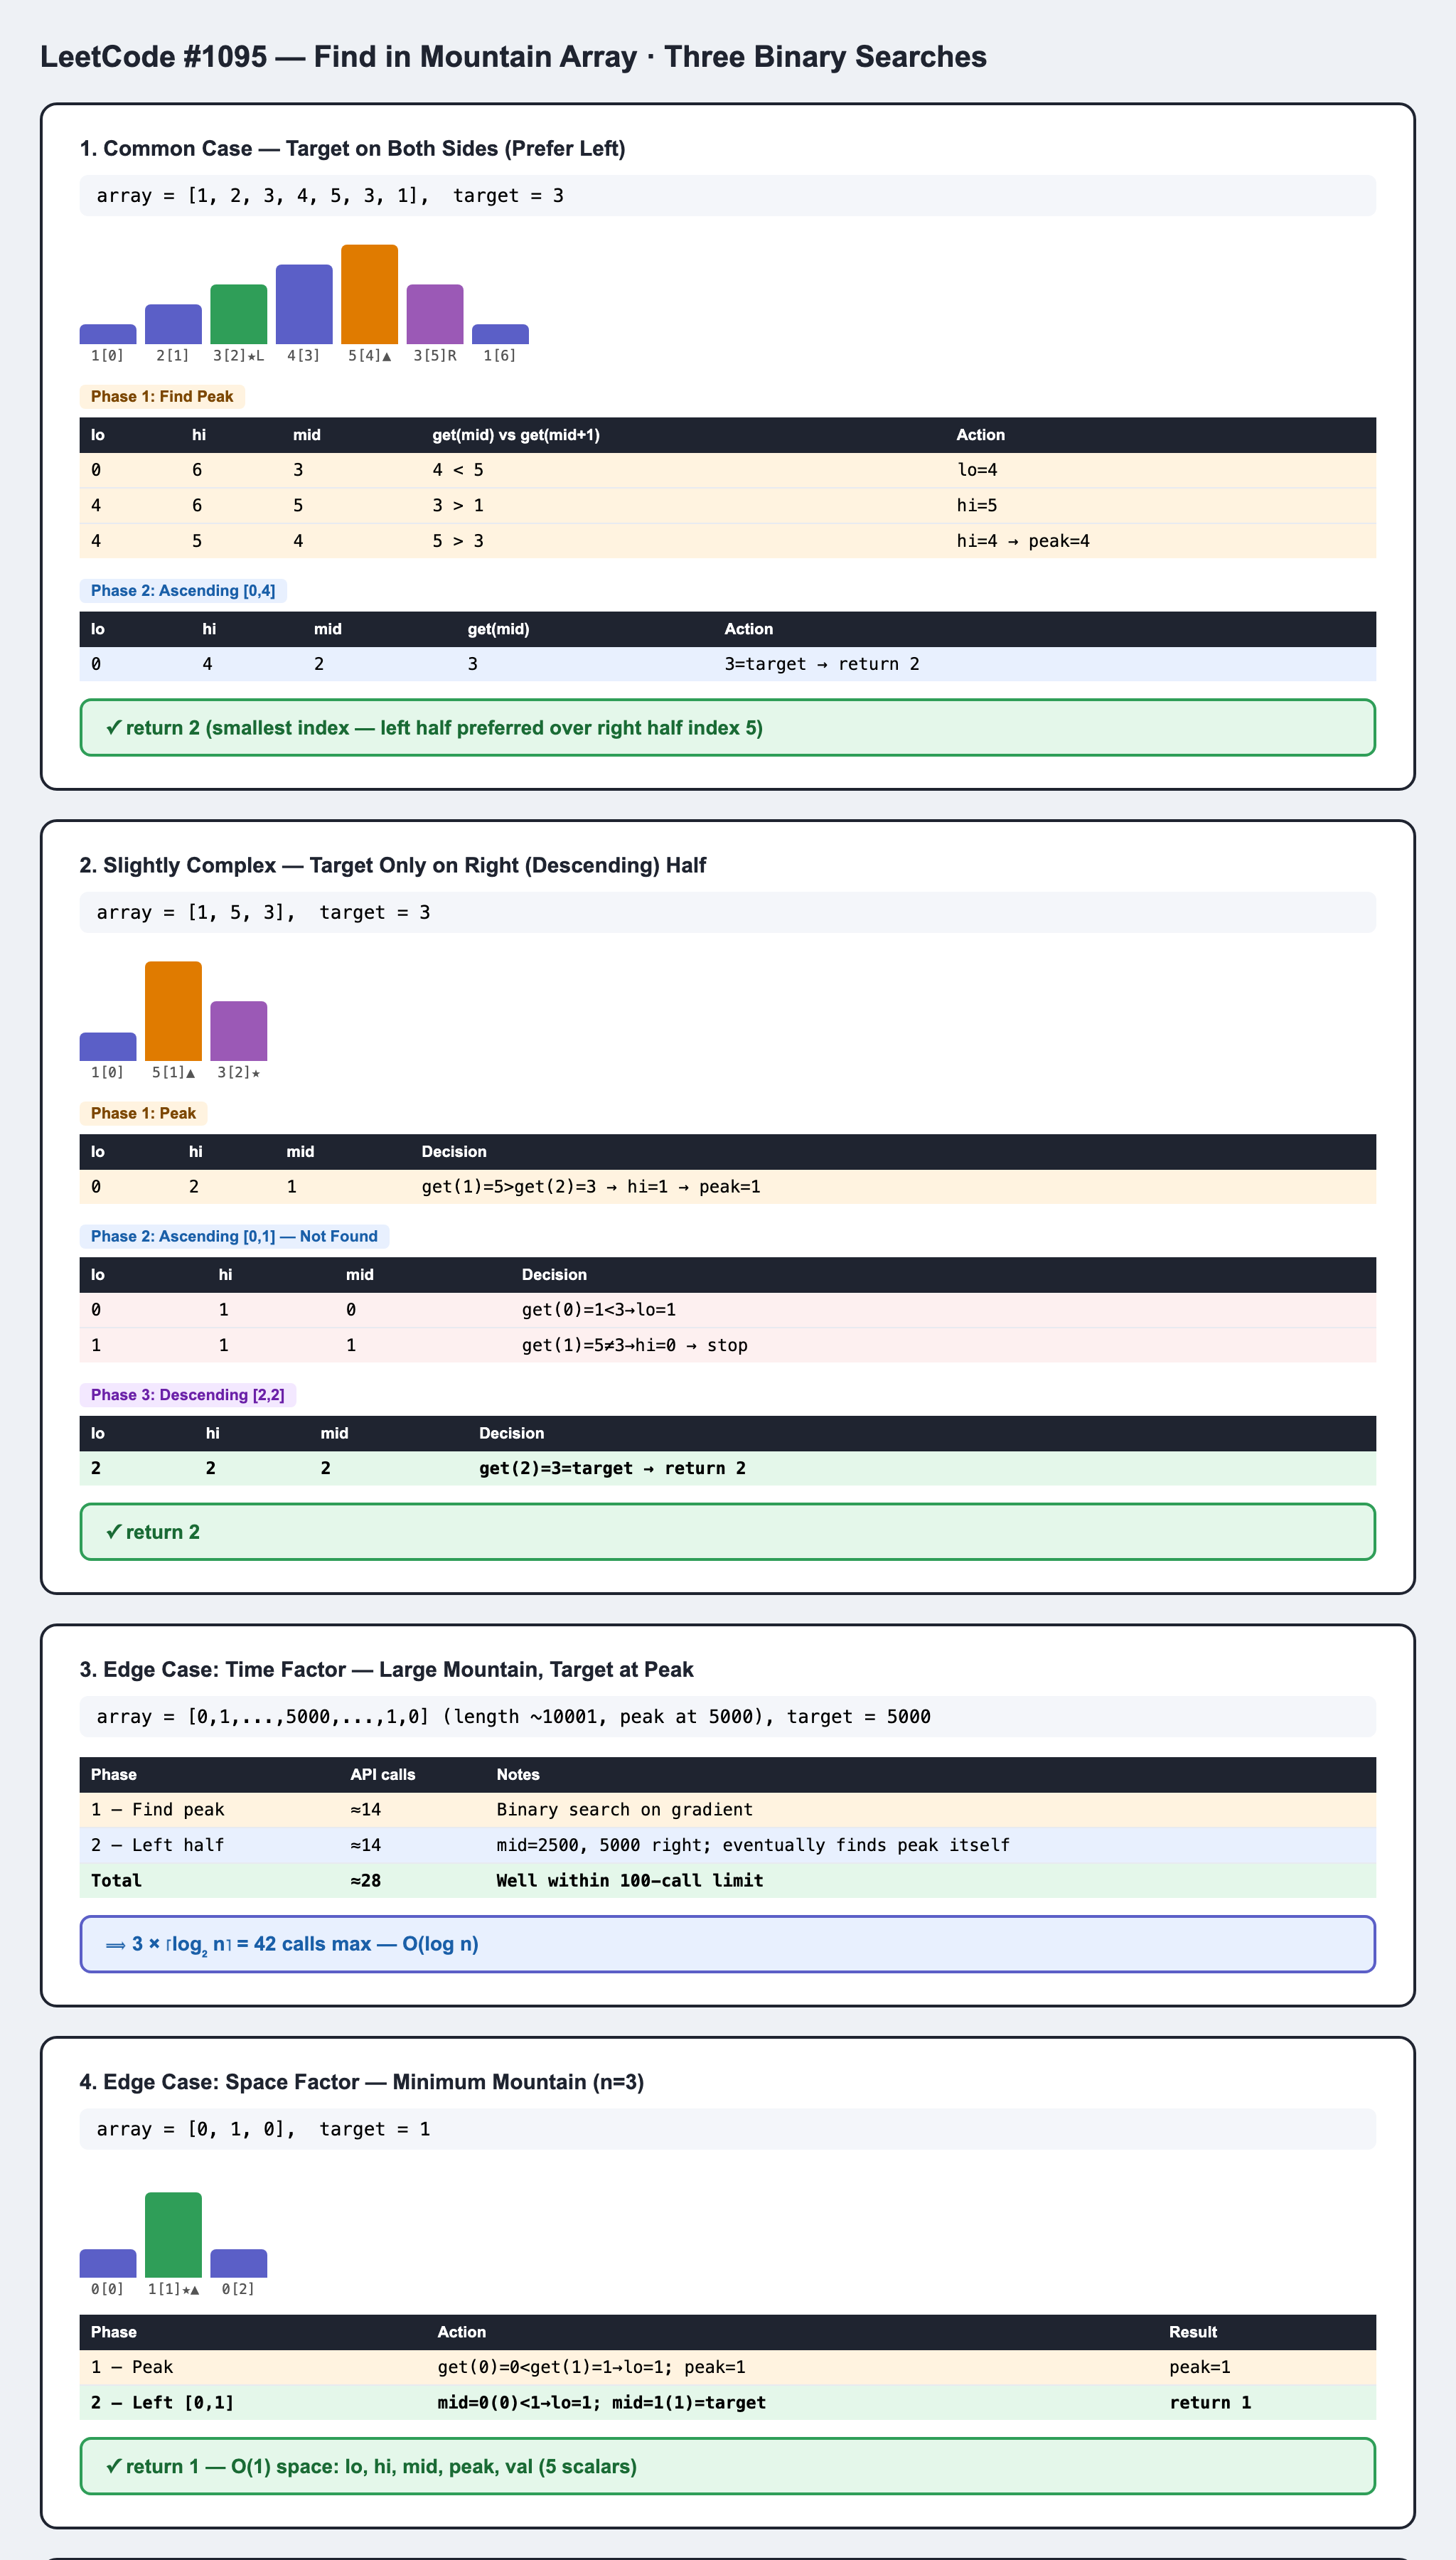